In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [37]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [38]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [20]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [12]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [13]:
X = df.iloc[:,1:3]
y= df.iloc[:,0]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
X_train

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


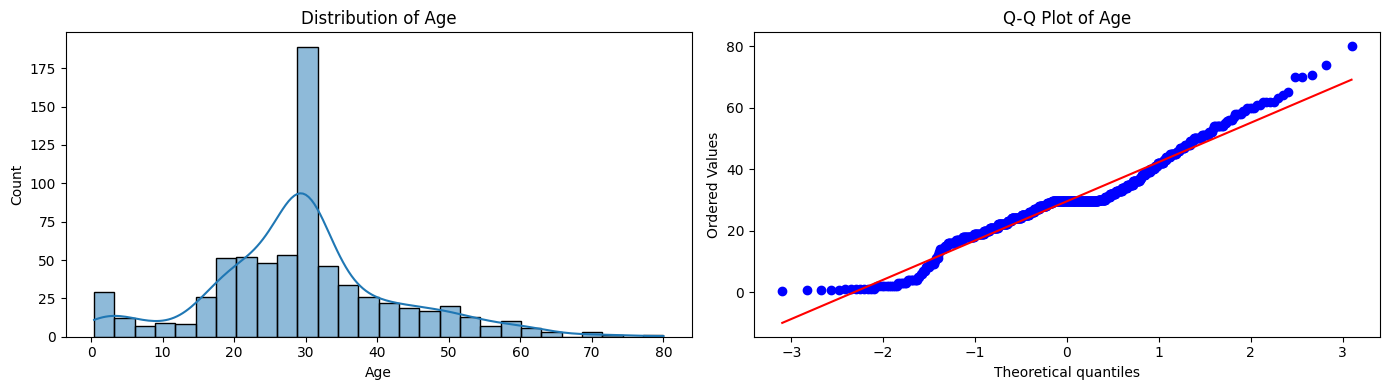

In [29]:
# Create the figure and subplots
plt.figure(figsize=(14, 4))

# Subplot 1: Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(X_train['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

# Subplot 2: Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Age')
plt.tight_layout()
plt.show()

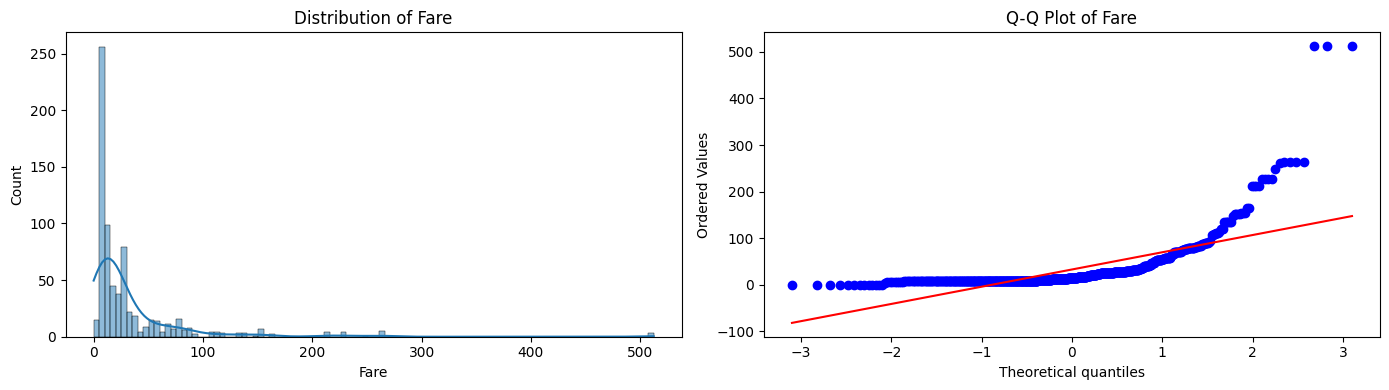

In [30]:
# Create the figure and subplots
plt.figure(figsize=(14, 4))

# Subplot 1: Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')

# Subplot 2: Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Fare')
plt.tight_layout()
plt.show()

In [31]:
#without transormation
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))

0.6480446927374302
0.664804469273743


In [32]:
#with transformer
trf = FunctionTransformer(func= np.log1p)

In [33]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [34]:

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)
print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))

0.6815642458100558
0.664804469273743


In [41]:

X_transformed = trf.fit_transform(X)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6543820224719101


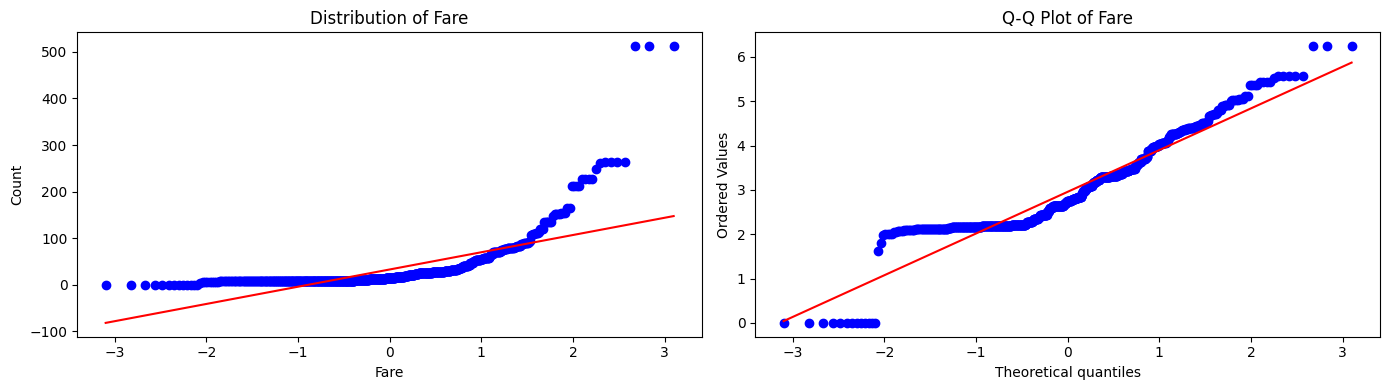

In [42]:

plt.figure(figsize=(14, 4))

# Subplot 1: Histogram with KDE
plt.subplot(1, 2, 1)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')

# Subplot 2: Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Fare')
plt.tight_layout()
plt.show()

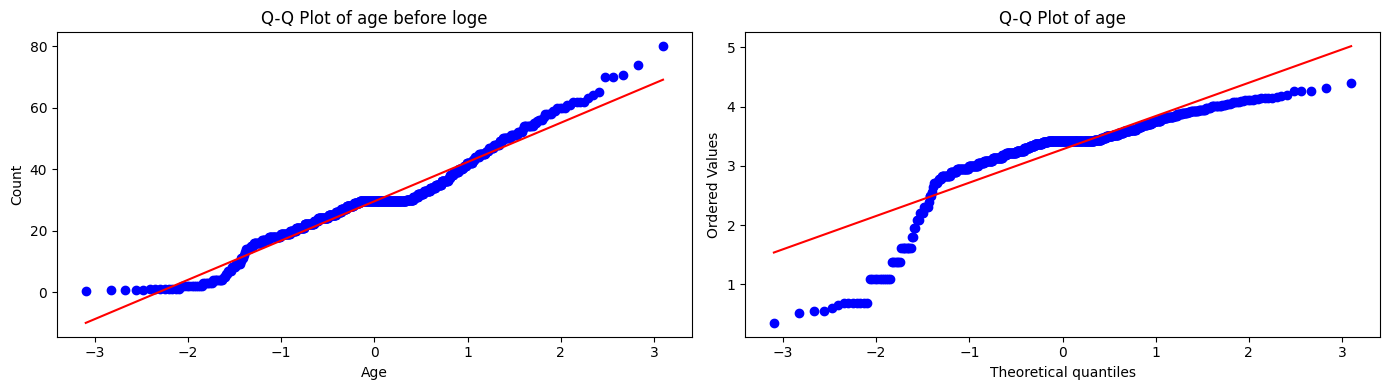

In [44]:

plt.figure(figsize=(14, 4))

# Subplot 1: Histogram with KDE
plt.subplot(1, 2, 1)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of age before log')
plt.xlabel('Age')
plt.ylabel('Count')

# Subplot 2: Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of age')
plt.tight_layout()
plt.show()

apply log transform only on fare


In [45]:
trf2 = ColumnTransformer(transformers=[
    ('log',FunctionTransformer(np.log1p),['Fare'])
],remainder='passthrough')

In [46]:
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [49]:

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))

0.6703910614525139
0.664804469273743


In [50]:

X_transformed2 = trf2.fit_transform(X)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6667041198501873


In [54]:
def apply_transform(transform):
  X = df.iloc[:,1:3]
  y= df.iloc[:,0]
  trf = ColumnTransformer(transformers=[
      ('log',FunctionTransformer(transform),['Fare'])
  ],remainder='passthrough')
  X_transformed = trf.fit_transform(X)
  clf = LogisticRegression()
  print("Accuracy",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))

  plt.figure(figsize=(14, 4))

  plt.subplot(1, 2, 1)
  stats.probplot(X['Fare'], dist="norm", plot=plt)
  plt.title('Fare before Transform')
  plt.xlabel('Fare')
  plt.ylabel('Count')

  plt.subplot(1, 2, 2)
  stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
  plt.title('Fare after Transform')
  plt.tight_layout()
  plt.show()




Accuracy 0.6589013732833957


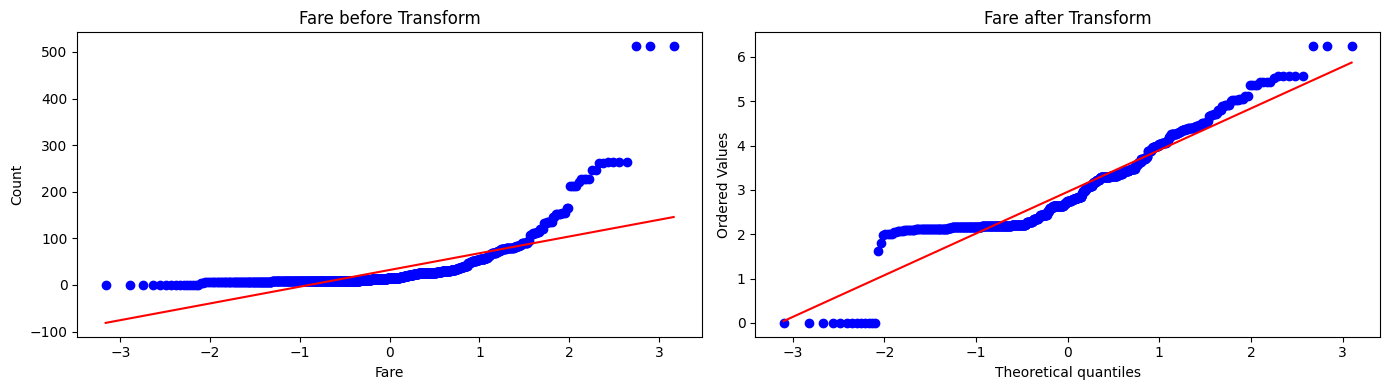

In [56]:
apply_transform(lambda x: x)